## Loading the data ##

In [15]:
from pathlib import Path
import pandas as pd
import xarray as xr

data_solar_energy = Path("Datasets/SARAH_3_SIS_20180101-20251010_daily.nc")
data_solar_production = Path("Datasets/Generation_2015-2024_hourly.csv")

pd_data_solar_energy = xr.open_dataset(data_solar_energy)
pd_data_solar_energy = pd_data_solar_energy.to_dataframe()

pd_data_solar_production = pd.read_csv(data_solar_production, sep=";")


In [16]:
print(pd_data_solar_production.columns)
#print(pd_data_solar_energy.columns)
#pd_data_solar_energy

Index(['Datum von', 'Datum bis', 'Biomasse [MWh] Berechnete Auflösungen',
       'Wasserkraft [MWh] Berechnete Auflösungen',
       'Wind Offshore [MWh] Berechnete Auflösungen',
       'Wind Onshore [MWh] Berechnete Auflösungen',
       'Photovoltaik [MWh] Berechnete Auflösungen',
       'Sonstige Erneuerbare [MWh] Berechnete Auflösungen',
       'Kernenergie [MWh] Berechnete Auflösungen',
       'Braunkohle [MWh] Berechnete Auflösungen',
       'Steinkohle [MWh] Berechnete Auflösungen',
       'Erdgas [MWh] Berechnete Auflösungen',
       'Pumpspeicher [MWh] Berechnete Auflösungen',
       'Sonstige Konventionelle [MWh] Berechnete Auflösungen'],
      dtype='object')


# Average SIS (solar surface irradiance) in $\mathrm{W/m^2}$ over the entire period recorded #

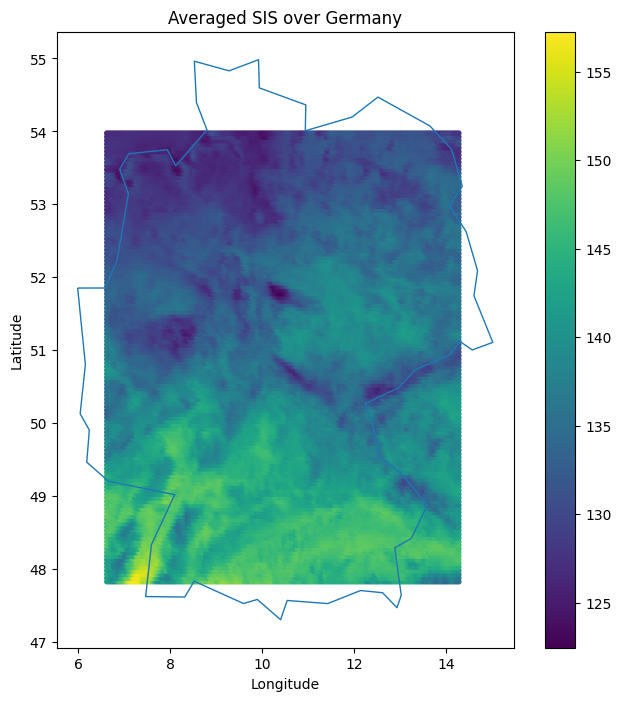

In [24]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

df_data_solar_energy_full = pd_data_solar_energy.reset_index()

# Average over time
mean_sis = df_data_solar_energy_full.groupby(["lat", "lon"], as_index=False)["SIS"].mean()

# GeoDataFrame
gdf = gpd.GeoDataFrame(mean_sis, geometry=gpd.points_from_xy(mean_sis["lon"], mean_sis["lat"]), crs="EPSG:4326")

# Coutry boundaries
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

germany = world[world["ADMIN"] == "Germany"]

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
germany.boundary.plot(ax=ax, linewidth=1)
gdf.plot(ax=ax, column="SIS", legend=True, markersize=10)

ax.set_title("Averaged SIS over Germany")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


# Prediction of total installed PV capacity in Germany #

In [ ]:
# You can adapt the values in this cell

start_date = "2019-01-01"
end_date   = "2024-12-31"

# geschätzte installierte PV-Leistung in DE (anpassen!)
total_pv_MW = 99000  

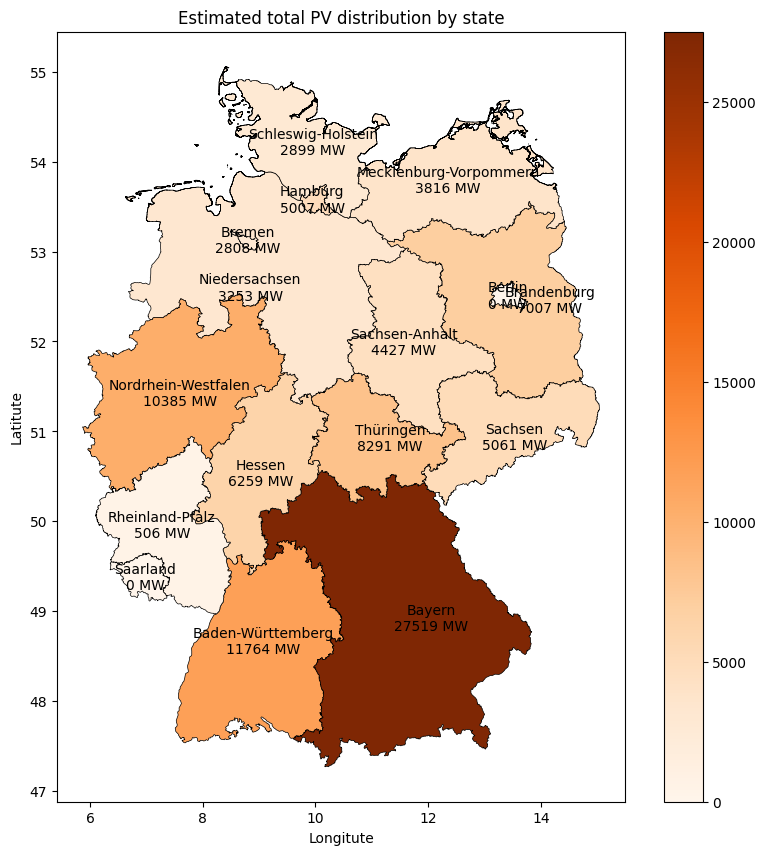

In [40]:
import numpy as np
from sklearn.linear_model import Ridge

# Preprocessing
sis = pd_data_solar_energy["SIS"].reset_index()
sis["time"] = pd.to_datetime(sis["time"])
mask_time = (sis["time"] >= start_date) & (sis["time"] <= end_date)
sis = sis[mask_time]
sis["time_day"] = sis["time"].dt.floor("D")

# Loading the shape of the states
states = gpd.read_file("https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/master/2_bundeslaender/1_sehr_hoch.geo.json")
states = states.to_crs(epsg=4326)

# Get all grid cells
grid = sis[["lat", "lon"]].drop_duplicates()

# Create a gdf of all the grid cells
grid_gdf = gpd.GeoDataFrame(grid, geometry=gpd.points_from_xy(grid["lon"], grid["lat"]), crs="EPSG:4326")

# Match grid cells and states
grid_and_state = gpd.sjoin(grid_gdf, states[["name", "geometry"]], how="inner", predicate="within")[["lat", "lon", "name"]]

# Conversion back to DF
grid_and_state = pd.DataFrame(grid_and_state)

# Add the states to sis data
sis_and_state = sis.merge(grid_and_state, on=["lat", "lon"], how="inner")

# daily average per state
sis_state_daily_average = sis_and_state.groupby(["time_day", "name"])["SIS"].mean().unstack("name")


# Preprocess the SMARD date on the total PV production in Germany
pv_raw = pd_data_solar_production.copy()
pv_raw["Datum von"] = pd.to_datetime(pv_raw["Datum von"], format="%d.%m.%Y %H:%M")
pv_raw["PV_MWh"] = pv_raw["Photovoltaik [MWh] Berechnete Auflösungen"].astype(str).str.replace(".", "", regex=False).str.replace(",", ".", regex=False).replace({"": np.nan, "-": np.nan}).astype(float)

pv_hourly = pv_raw.set_index("Datum von")["PV_MWh"]

# time window + daily sampling
pv_daily_sum = pv_hourly.loc[start_date:end_date].resample("D").sum()


# Linear Regression

common_days = sis_state_daily_average.index.intersection(pv_daily_sum.index)

X_df = sis_state_daily_average.loc[common_days].copy()
y_df = pv_daily_sum.loc[common_days]

# in Arrays
X = X_df.to_numpy()
y = y_df.to_numpy()

model = Ridge(alpha=1.0, fit_intercept=True, positive=True, solver="lbfgs")
model.fit(X, y)

weights = model.coef_
states_list = list(X_df.columns)

weights_states = pd.DataFrame({"state": states_list, "weight": weights})

# Calculate the relative proportion of each state
weights_states["rel_proportion"] = weights_states["weight"] / weights_states["weight"].sum()

weights_states["pv_MW_estimated"] = weights_states["rel_proportion"] * total_pv_MW

states_weights = states.merge(weights_states, left_on="name", right_on="state",how="left")


# Plotting

fig, ax = plt.subplots(figsize=(10, 10))

states_weights.plot(ax=ax, column="pv_MW_estimated", cmap="Oranges", legend=True, edgecolor="black", linewidth=0.5)

ax.set_title("Estimated total PV distribution by state")
ax.set_xlabel("Longitute")
ax.set_ylabel("Latitute")

for _, row in states_weights.iterrows():
    x, y = row["geometry"].representative_point().coords[0]
    ax.text(x, y, f'{row["name"]}\n{row["pv_MW_estimated"]:.0f} MW', ha="center", va="center", fontsize=10)

plt.show()

# Actual distribution of installed PV capacity in Germany (2024) #

<img src="photovoltaik-leistung-deutschland-karte.webp" width=500>